# Off-Policy TD Control with Q-Learning on SimplePURT

## Environment
Same environment from the Dynamic Programming and Monte Carlo demos

In [6]:
# Simple PURT Environment

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from enum import Enum

class Action(Enum):
    Right = 0
    Up = 1
    Left = 2
    Down = 3

class SimplePURT(gym.Env):
    # PYLON_COORDINATES: Bottom left corner is (0,0), Top right corner is (1,1)
    def __init__(self, GRID_N=10, MAX_STEPS=100, REWARDS={"neutral": 0, "midpoint": 1, "endpoint": 1, "pylon": -1}, NOISE=0, INIT_STATE=np.asarray([0, 0]), PYLON_COORDINATES=np.array([[0.2, 0.2],[0.2,0.8],[0.8,0.8],[0.8,0.2]])):
        super(SimplePURT, self).__init__()

        self.GRID_N = GRID_N
        self.MAX_STEPS = MAX_STEPS
        self.REWARDS = REWARDS
        self.NOISE = NOISE # [0,1] -- 0: No Noise, 1: 100% Noise
        self.INIT_STATE = INIT_STATE.copy()

        self.PYLON_GRID_COORDINATES = np.round(PYLON_COORDINATES * (GRID_N - 1)).astype(int) # Convert pylon coordinates to grid coordinates
        self.PYLON_GRID_INDICES = self.PYLON_GRID_COORDINATES[:, 0] + self.PYLON_GRID_COORDINATES[:, 1] * GRID_N # Convert grid coordinates to grid indices

        self.PYLON_MIDPOINT_COORDINATES = np.zeros_like(PYLON_COORDINATES)
        for i in range(PYLON_COORDINATES.shape[0]):
            self.PYLON_MIDPOINT_COORDINATES[i] = 0.5 * (PYLON_COORDINATES[i] + PYLON_COORDINATES[(i + 1) % PYLON_COORDINATES.shape[0]]) # Midpoint between pylon i and pylon (i+1)
        self.PYLON_MIDPOINT_GRID_COORDINATES = np.round(self.PYLON_MIDPOINT_COORDINATES * (GRID_N - 1)).astype(int) # Convert midpoint coordinates to grid coordinates
        self.PYLON_MIDPOINT_INDICES = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 0] + self.PYLON_MIDPOINT_GRID_COORDINATES[:, 1] * GRID_N # Convert grid coordinates to grid indices

        self.observation_space = spaces.MultiDiscrete([
            GRID_N * GRID_N, # Grid index number
            len(self.PYLON_MIDPOINT_INDICES) + 1 # Number of midpoints visited
        ])
        self.action_space = spaces.Discrete(4) # Action space
        self.state = INIT_STATE.copy() # Initial state
        self.n_steps = 0 # Keep track of the number of steps taken
        self.state_history = [INIT_STATE.copy()] # Keep track of the state history
        self.action_history = [] # Keep track of the action history
        self.reward_history = [] # Keep track of the reward history

    def reset(self):
        self.state = self.INIT_STATE.copy()
        self.n_steps = 0
        self.state_history = [self.state.copy()]
        self.action_history = []
        self.reward_history = []
        return self.get_observation(), self.get_info()

    def step(self, action, ignore_truncation=False):
        new_state = self.state.copy()
        reward = self.REWARDS["neutral"]
        done = False
        truncated = False

        # 2D movement
        new_state[0] = self.get_new_position(action)

        # Reward
        if new_state[0] != self.state[0]:
            if new_state[0] in self.PYLON_GRID_INDICES:
                reward += self.REWARDS["pylon"] # Penalty for hitting a pylon
                done = True
            elif new_state[1] < len(self.PYLON_MIDPOINT_INDICES):
                if new_state[0] == self.PYLON_MIDPOINT_INDICES[new_state[1]]:
                    reward += self.REWARDS["midpoint"] # Reward for visiting midpoints in order
                    new_state[1] += 1 # Move to the next midpoint
            elif new_state[0] == self.INIT_STATE[0]:
                reward += self.REWARDS["endpoint"] # Reward for returning to initial state
                done = True
        else:
            done = True # If the agent tries to move out of bounds, end the episode

        self.state = new_state
        self.state_history.append(new_state.copy())
        self.action_history.append(action)
        self.reward_history.append(reward)

        if not ignore_truncation:
            self.n_steps += 1
            truncated = self.n_steps >= self.MAX_STEPS # Truncate the episode after MAX_STEPS

        return self.get_observation(), reward, done, truncated, self.get_info()

    def get_observation(self):
        return self.state

    def get_info(self):
        return {"state_history": self.state_history, "action_history": self.action_history, "reward_history": self.reward_history}

    def get_possible_next_states(self, action):
        # 1. Determine probabilities for noise tendencies
        # Noise = 0 -> prob_intended = 1.0, prob_dev = 0.0
        p_dev = self.NOISE / 3.0
        p_intended = 1.0 - (2.0 * p_dev)

        # Map tendencies (-1: left shift, 0: intended, 1: right shift) to probabilities
        tendencies = [
            (0, p_intended),
            (-1, p_dev),
            (1, p_dev)
        ]

        possible_transitions = {} # Key: (next_position, next_midpoint_count), Value: [prob, reward]

        for tendency, prob in tendencies:
            if prob <= 0:
                continue  # Skip zero-probability transitions

            # Determine effective action based on tendency logic from get_new_position
            transition = Action(action)
            if tendency != 0:
                match transition:
                    case Action.Up:
                        transition = Action.Right if tendency == 1 else Action.Left
                    case Action.Down:
                        transition = Action.Left if tendency == 1 else Action.Right
                    case Action.Left:
                        transition = Action.Up if tendency == 1 else Action.Down
                    case Action.Right:
                        transition = Action.Down if tendency == 1 else Action.Up

            # Compute next grid position index
            curr_pos = self.state[0]
            match transition:
                case Action.Up:
                    new_pos = (curr_pos + self.GRID_N) if curr_pos < self.GRID_N * (self.GRID_N - 1) else curr_pos
                case Action.Down:
                    new_pos = (curr_pos - self.GRID_N) if curr_pos >= self.GRID_N else curr_pos
                case Action.Left:
                    new_pos = (curr_pos - 1) if curr_pos % self.GRID_N != 0 else curr_pos
                case Action.Right:
                    new_pos = (curr_pos + 1) if (curr_pos + 1) % self.GRID_N != 0 else curr_pos

            # Calculate reward and next state logic matching step()
            new_state = self.state.copy()
            reward = self.REWARDS["neutral"]
            done = False

            if new_pos != curr_pos:
                new_state[0] = new_pos
                if new_pos in self.PYLON_GRID_INDICES:
                    reward += self.REWARDS["pylon"]
                    done = True
                elif new_state[1] < len(self.PYLON_MIDPOINT_INDICES):
                    if new_pos == self.PYLON_MIDPOINT_INDICES[new_state[1]]:
                        reward += self.REWARDS["midpoint"]
                        new_state[1] += 1
                elif new_pos == self.INIT_STATE[0]:
                    reward += self.REWARDS["endpoint"]
            else:
                # Out-of-bounds boundary bump
                done = True
                pass

            state_key = (int(new_state[0]), int(new_state[1]))

            # Aggregate probabilities if different noise tendencies lead to identical outcome states
            if state_key in possible_transitions:
                possible_transitions[state_key][0] += prob
            else:
                possible_transitions[state_key] = [prob, reward, done]

        # Convert results into required format [[next_state_array, prob, reward], ...]
        results = []
        for (pos, midpoints_visited), (p, r, d) in possible_transitions.items():
            next_state_arr = np.array([pos, midpoints_visited], dtype=int)
            results.append([next_state_arr, p, r, d])

        return results

    def get_new_position(self, action):
        # 1. Simplify noise sampling (equivalent to your normal ppf logic)
        p_dev = self.NOISE / 3.0
        tendency = np.random.choice([-1, 0, 1], p=[p_dev, 1 - 2 * p_dev, p_dev])

        # 2. Resolve direction shift if noise occurs
        transition = Action(action)
        if tendency != 0:
            match transition:
                case Action.Up:
                    transition = Action.Right if tendency == 1 else Action.Left
                case Action.Down:
                    transition = Action.Left if tendency == 1 else Action.Right
                case Action.Left:
                    transition = Action.Up if tendency == 1 else Action.Down
                case Action.Right:
                    transition = Action.Down if tendency == 1 else Action.Up

        # 3. Calculate grid position with boundary limits
        curr_pos = self.state[0]
        match transition:
            case Action.Up:
                return (curr_pos + self.GRID_N) if curr_pos < self.GRID_N * (self.GRID_N - 1) else curr_pos
            case Action.Down:
                return (curr_pos - self.GRID_N) if curr_pos >= self.GRID_N else curr_pos
            case Action.Left:
                return (curr_pos - 1) if curr_pos % self.GRID_N != 0 else curr_pos
            case Action.Right:
                return (curr_pos + 1) if (curr_pos + 1) % self.GRID_N != 0 else curr_pos

    def render(self, ax=None, title=None, legend_outside=True):
        # 1. Initialize the plot (or draw into a caller-provided axes for side-by-side comparisons)
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_xlim(-0.5, self.GRID_N - 0.5)
        ax.set_ylim(-0.5, self.GRID_N - 0.5)

        # Configure grid lines to match your matrix index boundary points
        ax.set_xticks(np.arange(self.GRID_N))
        ax.set_yticks(np.arange(self.GRID_N))
        ax.grid(True, which='both', color='gainsboro', linestyle='-', linewidth=0.5)

        # 2. Extract and Plot Pylons (|)
        px = self.PYLON_GRID_COORDINATES[:, 0]
        py = self.PYLON_GRID_COORDINATES[:, 1]
        ax.scatter(px, py, color='firebrick', marker='|', s=250, linewidths=3, label='Pylon')

        # 3. Extract and Plot Midpoints (o)
        mx = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 0]
        my = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 1]
        ax.scatter(mx, my, color='darkorange', marker='o', s=100, facecolors='none', edgecolors='darkorange', linewidths=2, label='Midpoint')

        # 4. Process and Plot Agent Path Line (With Smooth Continuous Gradient)
        if self.state_history:
            path_x = np.array([state[0] % self.GRID_N for state in self.state_history])
            path_y = np.array([state[0] // self.GRID_N for state in self.state_history])

            # --- Continuous Gradient Line Implementation via Interpolation ---
            if len(path_x) > 1:
                # Interpolate 100 fine points between every step to blend colors flawlessly
                num_interp_points = (len(path_x) - 1) * 100
                t_original = np.arange(len(path_x))
                t_fine = np.linspace(0, len(path_x) - 1, num_interp_points)

                fine_x = np.interp(t_fine, t_original, path_x)
                fine_y = np.interp(t_fine, t_original, path_y)

                # Reshape the upscaled points into micro-segments
                points = np.array([fine_x, fine_y]).T.reshape(-1, 1, 2)
                segments = np.concatenate([points[:-1], points[1:]], axis=1)

                # --- CONTROLLING THE COLOR SHIFT RATE ---
                # Default was np.linspace(0, 1, len(segments))
                # Adjust 'max_shift' to control how far along the colormap the path gets.
                # 0.4 means it will only shift through 40% of the colormap over the entire path.
                max_shift = 1
                path_progression = np.linspace(0, max_shift, len(segments))
                # ----------------------------------------

                lc = LineCollection(segments, cmap='plasma', linewidths=3, alpha=0.9, zorder=2)
                lc.set_array(path_progression)

                # CRITICAL: Fix the colormap scaling limits so 1.0 remains the absolute ceiling
                lc.set_clim(0, 1)

                ax.add_collection(lc)

                # Add a dummy handle so 'Agent Path' still shows up nicely in the legend
                from matplotlib.lines import Line2D
                legend_dummy = Line2D([0], [0], color=plt.get_cmap('plasma')(0.5), lw=3, label='Agent Path')
                # We will handle adding this dummy to the legend safely below
            # -----------------------------------------------------------------

            # Overlay directional action markers at each step along the line
            action_markers = {Action.Up.value: '^', Action.Down.value: 'v', Action.Left.value: '<', Action.Right.value: '>'}
            for i, action in enumerate(self.action_history):
                if action in action_markers:
                    ax.scatter(path_x[i], path_y[i], color='dodgerblue', marker=action_markers[action], s=80, zorder=3)

            # Distinctly mark Start and Finish states
            ax.scatter(path_x[0], path_y[0], color='forestgreen', marker='s', s=120, label='Start', zorder=4)
            ax.scatter(path_x[-1], path_y[-1], color='gold', marker='*', s=250, edgecolor='black', label='Finish', zorder=4)

        # 5. Labels and Legends
        ax.set_title(title or "SimplePURT Grid Visualization", fontsize=14, fontweight='bold', pad=15)
        ax.set_aspect('equal')

        # Adjust legend rendering to cleanly include our gradient dummy line
        handles, labels = ax.get_legend_handles_labels()
        if self.state_history and len(path_x) > 1:
            handles.append(legend_dummy)
            labels.append('Agent Path')
        if legend_outside:
            ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
        else:
            # Compact in-axes legend so multiple subplots can sit side by side without overlapping
            ax.legend(handles, labels, loc='upper right', fontsize=8, framealpha=0.9)

        if standalone:
            plt.tight_layout()
            plt.show()

Helper functions for interacting with the environment: sampling actions from a stochastic policy matrix (as before), and choosing actions $\varepsilon$-greedily directly from a $Q$-table (used by TD control, which acts off a $Q$-table rather than an explicit policy array)

In [7]:
def sample_action(policy, state):
    action_probs = policy[*state] # Action probabilities (must sum to 1)
    return np.random.choice(np.size(action_probs,0), p=action_probs) # Action sampling

def run_episode(env, policy, render_result=False):
    while True:
        action = sample_action(policy, env.state)
        observation, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break
    if render_result:
        env.render()
    return env.get_info()

def epsilon_greedy_action(Q, state, epsilon):
    # Choose an action epsilon-greedily with respect to Q(state, .); used by TD control,
    # which acts directly off a Q-table instead of an explicit policy array
    if np.random.random() < epsilon:
        return np.random.randint(Q.shape[-1])
    return np.argmax(Q[*state])

Value iteration to use as a baseline

In [8]:
# Value iteration function
def value_iteration(env, discount_factor, theta):
    V = np.zeros(env.observation_space.nvec, dtype=np.float64) # Initialize state-value function
    n_iter = 0

    # 1. Find V* by sweeping the Bellman Optimality equation until it converges
    while True:
        n_iter += 1
        delta = 0
        for s in np.ndindex(*env.observation_space.nvec):
            s = np.asarray(s)
            old_v = V[*s]
            Q = np.zeros(env.action_space.n, dtype=np.float64)
            for a in range(env.action_space.n):
                env.state = s # Set the environment state to the current state
                for next_state, prob, reward, done in env.get_possible_next_states(a):
                    Q[a] += prob * (reward + discount_factor * V[*next_state] * (1 - done))
            V[*s] = np.max(Q) # max instead of following a fixed policy
            delta = max(delta, np.abs(old_v - V[*s]))
        if delta < theta:
            break

    # 2. Extract the greedy policy from V* (with one final pass, no loop)
    policy = np.random.randint(env.action_space.n, size=env.observation_space.nvec, dtype=np.int8)
    for s in np.ndindex(*env.observation_space.nvec):
        s = np.asarray(s)
        Q = np.zeros(env.action_space.n, dtype=np.float64)
        for a in range(env.action_space.n):
            env.state = s
            for next_state, prob, reward, done in env.get_possible_next_states(a):
                Q[a] += prob * (reward + discount_factor * V[*next_state] * (1 - done))
        policy[*s] = np.argmax(Q)

    policy = np.eye(env.action_space.n)[policy]
    return policy, V, n_iter

## Q-Learning: Off-Policy TD Control

In [9]:
def q_learning(env, discount_factor, alpha, epsilon, n_episodes):
    # Initialize Q arbitrarily
    Q = np.random.random([*env.observation_space.nvec, env.action_space.n])

    for i in range(n_episodes):
        state, _ = env.reset()

        while True:
            # Behavior policy: epsilon-greedy with respect to Q
            action = epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, done, truncated, info = env.step(action)

            # Q-Learning update -- bootstraps off max_a Q(S', a), the greedy action,
            # regardless of which action the behavior policy actually selects next
            Q[*state, action] += alpha * (reward + discount_factor * np.max(Q[*next_state]) * (1 - done) - Q[*state, action])

            state = next_state
            if done or truncated:
                break

    return Q

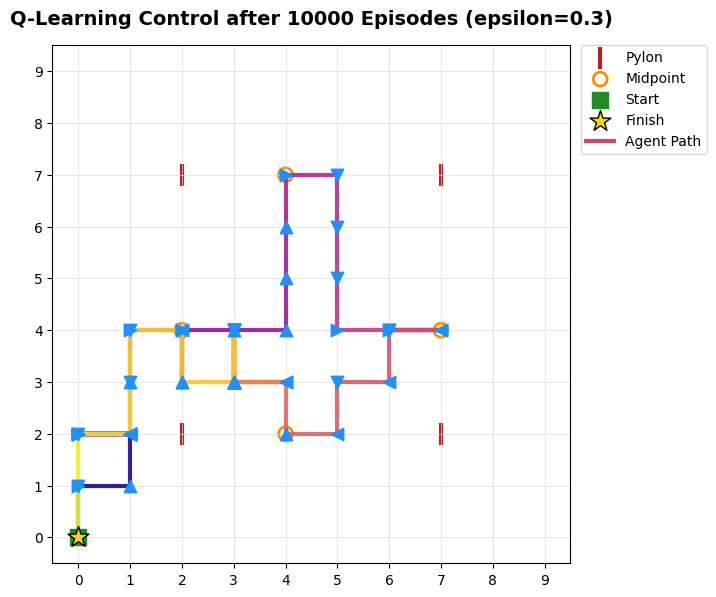

In [10]:
from tqdm import tqdm

env1 = SimplePURT(NOISE=0.25)
discount_factor1 = 0.99
alpha1 = 0.1
VI_policy, VI_V, n_iter = value_iteration(env1, discount_factor1, 0.01)

q_learning_Q = q_learning(env1, discount_factor1, alpha1, 0.3, 10000)
q_learning_policy = np.eye(env1.action_space.n)[np.argmax(q_learning_Q, axis=2)]
env1.reset()
while len(env1.state_history) < 20:
    env1.reset()
    run_episode(env1, q_learning_policy)
env1.render(title="Q-Learning Control after 10000 Episodes (epsilon=0.3)")

### Convergence of the Off-Policy Target

100%|██████████| 100/100 [00:00<00:00, 205.79it/s]


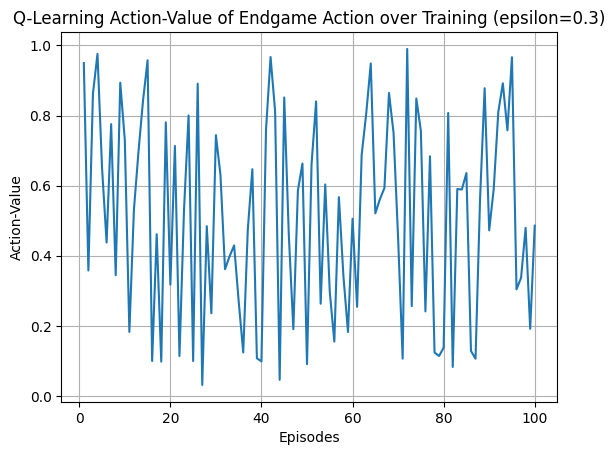

In [11]:
nrange1 = range(1,101,1)
q_learning_Q_progress = []
for n in tqdm(nrange1):
    q_learning_Q_progress.append(q_learning(env1, discount_factor1, alpha1, 0.3, n)[1,4,2])
plt.plot(nrange1, q_learning_Q_progress)
plt.title("Q-Learning Action-Value of Endgame Action over Training (epsilon=0.3)")
plt.xlabel("Episodes")
plt.ylabel("Action-Value")
plt.grid(True)